In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
data1 = pd.read_csv("../model2/train_history.csv")
data1.head()

,epoch,train_loss,train_accuracy,train_f1_macro,val_loss,val_accuracy,val_f1_macro,best_val_f1_macro,is_best
0,1,1.804227,0.161099,0.154187,1.801591,0.157974,0.150940,0.150940,1
1,2,1.803522,0.162207,0.155191,1.800851,0.162774,0.156382,0.156382,1
2,3,1.802829,0.163385,0.156200,1.800172,0.167148,0.160668,0.160668,1
3,4,1.802148,0.164570,0.157157,1.799568,0.175004,0.166824,0.166824,1
4,5,1.801472,0.165837,0.158130,1.799006,0.178023,0.168146,0.168146,1


In [14]:
data2_raw = pd.read_csv("./train_history.csv")

# Mỗi lần epoch quay về 1 là một training run mới. CSV hiện tại đã bị
# append nhiều run, nên giữ run liên tục dài nhất và bỏ các run trùng/ngắn.
run_id = data2_raw["epoch"].le(data2_raw["epoch"].shift()).cumsum()
longest_run_id = run_id.value_counts().idxmax()
data2 = data2_raw.loc[run_id.eq(longest_run_id)].copy().reset_index(drop=True)

# model2 kết thúc ở epoch 100; model3 bắt đầu lại từ 1 vì checkpoint model2
# không lưu epoch. Dịch epoch để history nối thành 101, 102, ...
data2["epoch"] = data2["epoch"] + int(data1["epoch"].max())
data2[["epoch", "train_loss", "val_loss"]].head()

,epoch,train_loss,val_loss
0,101,0.936574,0.791232
1,102,0.923687,0.780557
2,103,0.910940,0.770407
3,104,0.898053,0.762901
4,105,0.885141,0.755377


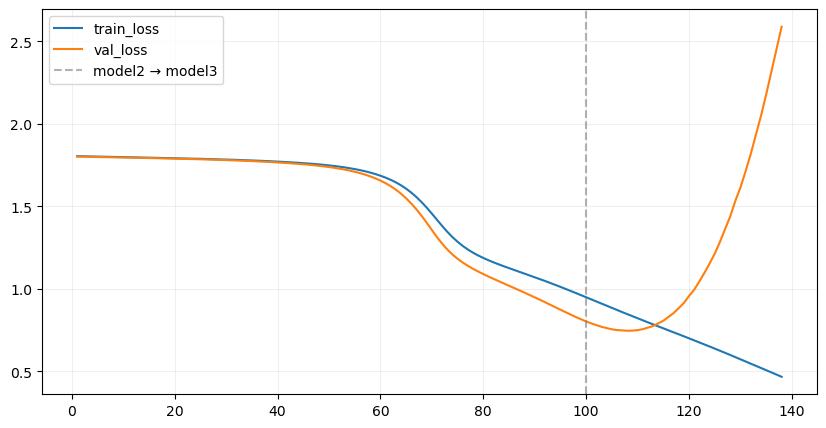

In [16]:
data = pd.concat([data1, data2], ignore_index=True)
data = data.sort_values("epoch").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(data["epoch"], data["train_loss"], label="train_loss")
ax.plot(data["epoch"], data["val_loss"], label="val_loss")
ax.axvline(data1["epoch"].max(), color="gray", linestyle="--", alpha=0.6, label="model2 → model3")
ax.legend()
ax.grid(alpha=0.2)
plt.show()